# 502 — one cell, one def

Every step lives in `pipe_502.py`. Nothing here holds state: it all lives in `S`
inside the module, so a crash costs you one cell, not the whole notebook.

In [3]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
sys.path.insert(0, "")          # this folder, so pipe_502 imports
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from ZZ_MASTER_SWITCH_PYTHON import *

timer_start()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## RESTART HERE

Kernel died? Run this one cell. It re-derives config, paths, the Producer's flags,
the paper edit, the recon jobs, every solved reconstruction and the GPS calibration —
without re-running Gemini, ASR, SAM3, the Producer agent or a VGGT solve.

Not restored (they cost money or a GPU): `reid_match()`, `subject_positions()`.

In [4]:
restore()

project_root: /workspace/project
Case    : 502_EGO_BIKE
Video   : aria05_214-1_fullres_undistorted_with_audio.mp4
video fps: 30.000
total_frames 7813
{'VID_TO_TEXT': True, 'TRACKING': False, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': False, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': False, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}
1
/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json
/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json
=== Derived flags (from 502_EGO_BIKE_Pipe_eval_01_1_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": false,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION": false,
  "MASK_OVERLAYS": true,
  "MULTICAM": false
}
{'GPS_signal': 'no'}
/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tracking missing for new_inner_tube
{'GPS_signal': 'no',
 'bicycle_wheel-01': {'Subject_frames_present': [0,
                                                 1,
                                                 2,
                                                 3,
                                                 4,
                                                 5,
                                                 6,
                                                 7,
                                                 8,
                                                 9,
                                                 10,
                                                 11,
                                                 12,
                                                 13,
                                                 14,
                                                 15,
                                                 16,
                                                 17,

{'case_name': '502_EGO_BIKE',
 'experiment': 'Pipe_eval_01',
 'project_root': PosixPath('/workspace/project'),
 'case_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE'),
 'source_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/010_source'),
 'query_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/012_Gemini_outputs'),
 'masks_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/015_SAM3_masks/Pipe_eval_01'),
 'frames_for_cam_poses': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01'),
 'frames_for_recon': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_recon/Pipe_eval_01'),
 'VGGT_O_output_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01'),
 'ply_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01/ply'),
 'reg_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/030_Registrations/Pipe_eval_01'),
 'csv_path_GPS': PosixPath('/workspace/project/Data/502

In [5]:
state()      # what's currently in S

case_name                    502_EGO_BIKE
experiment                   Pipe_eval_01
project_root                 /workspace/project
case_dir                     /workspace/project/Data/502_EGO_BIKE
source_dir                   /workspace/project/Data/502_EGO_BIKE/010_source
query_dir                    /workspace/project/Data/502_EGO_BIKE/012_Gemini_outputs
masks_dir                    /workspace/project/Data/502_EGO_BIKE/015_SAM3_masks/Pipe_eval_01
frames_for_cam_poses         /workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01
frames_for_recon             /workspace/project/Data/502_EGO_BIKE/020_frames_for_recon/Pipe_eval_01
VGGT_O_output_dir            /workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01
ply_dir                      /workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01/ply
reg_dir                      /workspace/project/Data/502_EGO_BIKE/030_Registrations/Pipe_eval_01
csv_path_GPS                 /workspace/project

{'case_name': '502_EGO_BIKE',
 'experiment': 'Pipe_eval_01',
 'project_root': PosixPath('/workspace/project'),
 'case_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE'),
 'source_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/010_source'),
 'query_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/012_Gemini_outputs'),
 'masks_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/015_SAM3_masks/Pipe_eval_01'),
 'frames_for_cam_poses': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01'),
 'frames_for_recon': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_recon/Pipe_eval_01'),
 'VGGT_O_output_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01'),
 'ply_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/035_VGGT_O_output/Pipe_eval_01/ply'),
 'reg_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/030_Registrations/Pipe_eval_01'),
 'csv_path_GPS': PosixPath('/workspace/project/Data/502

# Config

In [ ]:
config()

In [ ]:
set_flags()

# AI First Pass

In [ ]:
gps()

In [ ]:
vid_to_text()

In [ ]:
# people()

In [ ]:
transcript()

## Producer 1

In [ ]:
passer(1)

In [ ]:
question("Make a video summary of this video")

In [ ]:
producer_draft1()

In [ ]:
# Feedback passes — was three commented-out cells, now one call:
# producer_draft2("The 3d Recon is too fast make it twice as long in duration")

In [ ]:
draft_tidy_up()          # re-run alone after hand-editing the paper edit
# load_producer_flags()  # just read the flags back, no re-render

# Tracking

In [ ]:
tracking_sam3()

In [ ]:
show_a2d()

In [ ]:
# tracking_sam3_manual("person")

In [ ]:
tracking_recovery()      # rebuild tracking from the mask folders after a restart

In [ ]:
paper_edit()

## Re ID

In [ ]:
reid_match()

In [ ]:
show_a2d()

In [ ]:
mask_check_maps()

In [ ]:
# mask_check_overlays()

# RECON
## Frame Selection

In [ ]:
build_jobs()

In [ ]:
frame_selection(capacity=200)

In [ ]:
# manual_frame_selection(start_frame=0, end_frame=7581, capacity=650)

## VGGT OMEGA — one solve per recon job

In [6]:
cuda_clear()

allocated GiB 0.0 reserved GiB 0.0
autocast enabled: False


In [7]:
vggt_omega()             # rerun_existing=True to force a re-solve

solving beat-06 MAP from /workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06
200 frames  →  /workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06
GPU freed -- 0.01 GiB still allocated, 0.39 GiB reserved
Saved: /workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06/predictions.npz
Saved: /workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06/scene.glb


# POST RECON
## Processing

In [8]:
load_recons()

beat-06 MAP: 200 camera poses


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

In [9]:
transform_poses_gps()

Cell disabled


## Recon Visualisation

In [10]:
export_plys()

beat-06 MAP -> /workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06/ply


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

In [11]:
visualise_plys()

beat-06 MAP: /workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06
Found 200 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

## ANALYSIS 3D

In [12]:
depth_confidence_stats()

--- beat-06 MAP ---
min, max confidence 1.0000019 20.884579
frames, y, x (200, 512, 512)
confidence percentiles [ 1.01438999  1.70553303  4.22812939  7.46141434 10.77768049]


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

## subject 3d positions

In [13]:
subject_positions()

/workspace/project/src/Q_subject_analysis.py:343: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:347: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:351: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R
/workspace/project/src/Q_subject_analysis.py:364: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


nan
nan
nan
271.41828184272464
nan
nan
nan
111.38155308591772
327.7964190782033
nan
nan
nan
nan
nan
nan
nan
nan
beat-06 MAP: ['yellow_tire_lever-01', 'bicycle_wheel_rim-01', 'person-01', 'person-02', 'person-03', 'person-04', 'bicycle_wheel-01', 'bicycle_wheel-02', 'bicycle_wheel-03', 'bicycle_wheel-04', 'bicycle_wheel-05', 'bicycle_wheel-06', 'bicycle_wheel-07', 'bicycle_wheel-08', 'bicycle_wheel-09']


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

In [14]:
show_jobs()

--- beat-06 MAP RECON_CAM_POSES 0-1800 ---
{'bicycle_wheel-01': {0: array([-0.3238142 ,  0.08116454,  0.48240879]),
                      9: array([-0.31873547,  0.08840892,  0.47555416]),
                      22: array([-0.29484333,  0.06468454,  0.48280205]),
                      28: array([-0.29618967,  0.07116532,  0.49274668]),
                      36: array([-0.2964808 ,  0.07485816,  0.49747997]),
                      43: array([-0.25434414,  0.13140949,  0.48426421]),
                      54: array([-0.16815214,  0.1449272 ,  0.45756115]),
                      218: array([0.23726571, 0.34450268, 0.45755239]),
                      225: array([0.42938984, 0.34272472, 0.68401667]),
                      234: array([0.55683099, 0.41100829, 0.79155971]),
                      240: array([1.1667212 , 0.51525295, 1.46701944]),
                      252: array([1.16367591, 0.55718597, 1.44024365]),
                      261: array([1.11975734, 0.575668  , 1.42743967]),
         

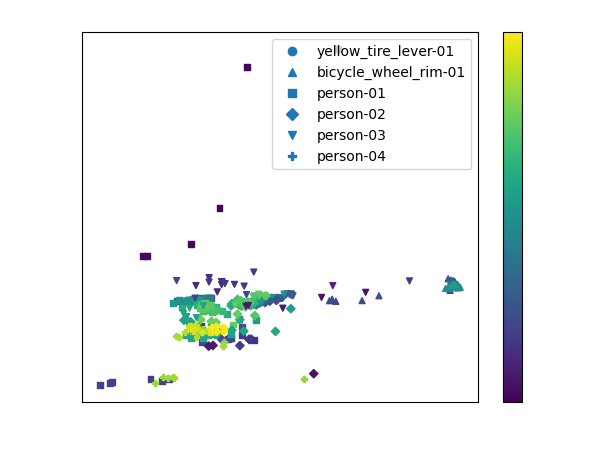

In [15]:
plot_positions_2d()

/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json
--- beat-06 MAP ---
{}


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

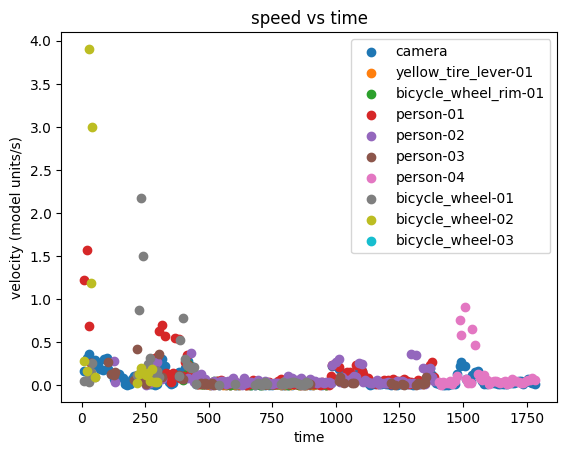

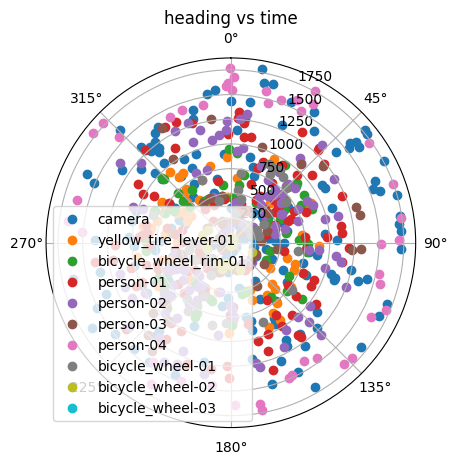

In [16]:
metrics_3d()

## TEMP TESTS — WIP

In [17]:
# depth_intersection_overlays("person-1", "the_large_sword-1")
# touching_test(job_index=0, contact_frame=386)

# PRODUCER 2

In [18]:
producer_flags()

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': True, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


{'TRACKING': True,
 'RECON_CAM_POSES': True,
 'RECON_3D': False,
 'GOOGLE_MAP': False,
 'BEV_MAP': True,
 'PROJECTION': False,
 'MASK_OVERLAYS': True,
 'MULTICAM': False}

In [19]:
find_cut_points()

/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json


PosixPath('/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json')

In [21]:
question()

Make a video summary of this video


'Make a video summary of this video'

In [22]:
producer_revision()

/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_draft.json
[18:41:29 +  0.00s] run_producer_agent: start
[18:41:29 +  0.00s] thread: start
[18:41:29 +  0.00s] event loop: created
[18:41:29 +  0.00s] query: start
[18:41:38 +  9.09s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=40006 cache_read=0
[18:41:38 +  9.09s] turn 1 content blocks: ['ThinkingBlock']
[18:41:38 +  9.09s] thinking:
I'm checking each beat's tracking results against its frame range: beat-04's tracking came back empty so I need to drop the overlay/subject data there, beat-02 and beat-03 got partial overlaps with their ranges, and beat-06's map returned too many ambiguous person and bicycle-wheel instances to use cleanly, so I'll flag that one.  With no overlaps found between beats, I'm ready to write the final output.
[18:41:56 + 26.21s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=40006 cache_read=0
[18:41:56 + 26.22s] turn 2 content blocks: ['ToolUseBloc

PosixPath('/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_revision.json')

In [23]:
match_beat_ids()

{'case_name': '502_EGO_BIKE',
 'brief': 'Make a video summary of this video',
 'beats': [{'archetype': 'ESTABLISHER',
   'order': 1,
   'beat_id': ['beat-01'],
   'segment_type': 'real',
   'duration_seconds': 8,
   'source': 'Wearer POV, 00:00-00:08 - seated in house garage holding bicycle wheel, bike on repair stand visible',
   'start_frame': 0,
   'end_frame': 316,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 10,
   'requested_flags': None,
   'quote': None,
   'rationale': 'R6.2 establisher under 10s; frame range returned at requested length',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': None},
  {'archetype': 'EVENT_TRIGGER',
   'order': 2,
   'beat_id': ['beat-02'],
   'segment_type': 'real',
   'duration_seconds': 14,
   'source': 'Wearer POV, 00:13-00:27 - yellow tire lever inserted under tire bead at valve stem',
   'start_frame': 374,
   'end_frame': 916,
   'lead_in_seconds': None,
   'search_win

In [24]:
find_cut_points()

/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_revision.json


PosixPath('/workspace/project/Data/502_EGO_BIKE/012_agent_p_output/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_revision.json')

# Rendering
## Projection

In [25]:
show_jobs()

--- beat-06 MAP RECON_CAM_POSES 0-1800 ---
{'bicycle_wheel-01': {0: array([-0.3238142 ,  0.08116454,  0.48240879]),
                      9: array([-0.31873547,  0.08840892,  0.47555416]),
                      22: array([-0.29484333,  0.06468454,  0.48280205]),
                      28: array([-0.29618967,  0.07116532,  0.49274668]),
                      36: array([-0.2964808 ,  0.07485816,  0.49747997]),
                      43: array([-0.25434414,  0.13140949,  0.48426421]),
                      54: array([-0.16815214,  0.1449272 ,  0.45756115]),
                      218: array([0.23726571, 0.34450268, 0.45755239]),
                      225: array([0.42938984, 0.34272472, 0.68401667]),
                      234: array([0.55683099, 0.41100829, 0.79155971]),
                      240: array([1.1667212 , 0.51525295, 1.46701944]),
                      252: array([1.16367591, 0.55718597, 1.44024365]),
                      261: array([1.11975734, 0.575668  , 1.42743967]),
         

In [26]:
projection()

no PROJECTION beats in this revision


## Mapping

In [27]:
animated_map()

In [28]:
times_of_day()

skipping attach_times_of_day: No creation_time metadata in /workspace/project/Data/502_EGO_BIKE/010_source/aria05_214-1_fullres_undistorted_with_audio.mp4


In [29]:
bev_setup()

beat-06 MAP: 200 frames in recon


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

In [30]:
bev_hires()

min depth tensor(0.0299, device='cuda:0')
torch.Size([20971513, 3])
mins, maxes and ranges -1.7118619740009309 1.796474701166153 3.508336675167084 -1.0539002299308777 2.1862432837486265 3.240143513679504
scale - original 1358.2575474720386
beat-06: /workspace/project/Data/502_EGO_BIKE/090_assets/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_BEV_tile_render_PM_beat-06.png


[{'beat_key': 'beat-06',
  'beat_ids': ['beat-06'],
  'order': 6,
  'archetype': 'MAP',
  'kind': 'MAP',
  'flag': 'RECON_CAM_POSES',
  'start_frame': 0,
  'end_frame': 1800,
  'frames_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/020_frames_for_cam_poses/Pipe_eval_01/beat-06'),
  'recon_dir': PosixPath('/workspace/project/Data/502_EGO_BIKE/031_Recon_MAP/Pipe_eval_01/beat-06'),
  'beat': {'archetype': 'MAP',
   'order': 6,
   'beat_id': ['beat-06'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 60,
   'requested_flags': ['BEV_MAP', 'RECON_CAM_POSES', 'TRACKING'],
   'quote': None,
   'rationale': 'R5.1 MAP mandatory; R5.2 GPS_signal no so BEV of garage workspace layout',
   'rejected_alternative': 'GOOGLE_MAP, ruled out by R5.2 with GPS_signal no',
   'flag': None,
   'tracked_subject': [{'gem_person_id': 

In [31]:
bev_trace_overlay()

Skipping subject trace 'subject' -- no frames overlap extra_indices.
frame 0000 t_frac=0.0000 [camera] virtual_frame=0.0 pos_px=(570.6, 728.7)
frame 0001 t_frac=0.0033 [camera] virtual_frame=6.0 pos_px=(570.7, 729.4)
frame 0002 t_frac=0.0067 [camera] virtual_frame=12.0 pos_px=(564.6, 725.4)
frame 0003 t_frac=0.0100 [camera] virtual_frame=18.0 pos_px=(552.0, 716.7)
frame 0004 t_frac=0.0134 [camera] virtual_frame=24.0 pos_px=(539.2, 706.6)
frame 0005 t_frac=0.0167 [camera] virtual_frame=29.9 pos_px=(528.2, 693.3)
frame 0006 t_frac=0.0201 [camera] virtual_frame=35.9 pos_px=(522.0, 679.1)
frame 0007 t_frac=0.0234 [camera] virtual_frame=41.9 pos_px=(526.1, 668.8)
frame 0008 t_frac=0.0268 [camera] virtual_frame=47.9 pos_px=(539.1, 659.2)
frame 0009 t_frac=0.0301 [camera] virtual_frame=53.9 pos_px=(554.0, 649.6)
frame 0010 t_frac=0.0334 [camera] virtual_frame=59.9 pos_px=(571.9, 656.7)
frame 0011 t_frac=0.0368 [camera] virtual_frame=65.9 pos_px=(589.9, 664.1)
frame 0012 t_frac=0.0401 [camera]

# Output

In [32]:
assemble_movie()

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-02


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-03


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

/workspace/project/Data/502_EGO_BIKE/090_assets/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_rough_cut.mp4


PosixPath('/workspace/project/Data/502_EGO_BIKE/090_assets/Pipe_eval_01/502_EGO_BIKE_Pipe_eval_01_1_rough_cut.mp4')

In [33]:
final_report()

On a quiet evening in a home garage workshop, a technician performs maintenance on a bicycle wheel assembly.

The bicycle wheel rim, highlighted in green, is actively worked on from frame 387 to frame 974. During this process, the wheel rim travels a net distance of 0.18 model units at a heading of 57.85 degrees, moving with an average speed of 0.02 model units/s.

A yellow tire lever, also highlighted in green, is used to pry the tire bead away from the rim between frame 450 and frame 974. This tool moves very subtly, covering a net distance of 0.01 model units at a heading of 261.36 degrees with an average speed of 0.01 model units/s.

Additionally, the old black inner tube is highlighted in green as it is pulled free from the tire casing between frame 2675 and frame 2864. No other people interact with or speak about the tools or wheel parts during this task.
**01:53** [person-01]: Okay.


In [34]:
timer_end()

[default] 1049.74s


1049.7422460466623

In [35]:
# populate_pptx("<template name>")